In [ ]:
import pandas as pd
import numpy as np
import random
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt 

Reading csv file with set of oil molecule

In [ ]:
molecules = "path to set of IR specra of all molecules.csv" 

Adding descriptor: moleclar weight

In [ ]:
def read_file_with_molecules(molecules): 
    df = pd.read_csv(molecules)
    df['colname'] = df['FRACTION'] + df['ID'].astype(str)
    df['Mw'] = df['SMILES'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))
    df.columns = df.columns.str.strip()
    df.set_index('colname', inplace=True)
    return df



In [ ]:
mol_wt = read_file_with_molecules(molecules)

Dividing on 5 subset of molecules

In [ ]:
df = mol_wt  

# Defining groups 
groups = {
    "S": df[df["FRACTION"] == "S"].sample(frac=1, random_state=42).reset_index(drop=True),
    "Ar": df[df["FRACTION"] == "Ar"].sample(frac=1, random_state=42).reset_index(drop=True),
    "R": df[df["FRACTION"] == "R"].sample(frac=1, random_state=42).reset_index(drop=True),
    "As": df[df["FRACTION"] == "As"].sample(frac=1, random_state=42).reset_index(drop=True),
}


n_tables = 5
n_per_group = 20


# Dividing the groups into 5 disjoint parts
splits = {name: np.array_split(group, n_tables) for name, group in groups.items()}

spectra_subsets = []
for i in range(n_tables):
    # Combining them into groups
    combined = pd.concat(
        [splits["S"][i].iloc[:n_per_group],
         splits["Ar"][i].iloc[:n_per_group],
         splits["R"][i].iloc[:n_per_group],
         splits["As"][i].iloc[:n_per_group]],
        ignore_index=True
    )

    # creating new indices
    new_index = (
        [f"S{j}" for j in range(1, 21)] +
        [f"Ar{j}" for j in range(21, 41)] +
        [f"R{j}" for j in range(41, 61)] +
        [f"As{j}" for j in range(61, 81)]
    )
    combined.index = new_index

    
    combined.to_csv(f"table_{i+1}.csv", index_label="colname")
    spectra_subsets.append(combined)






Generationg mole weight with corresponding SARA composition

In [ ]:
def generate_mole_fractions(n, molecules):
    #Getting dataframe where the columns are compounds, the rows are oil, n*l, n is the amount of oil, l is the number of compounds + 4 SARA fractions by mass
    random.seed(52)
    mole_fractions=[] #list of n variations of mole weight of compounds
    weight_log = [] # list of n variations of mass fractions of fractions
    base_df=molecules
    

    for i in range(n):
        df = base_df.copy()
        w_As = random.uniform(0, 0.1)
        w_R = random.uniform(0, 0.3)
        remaining = 1 - w_As - w_R
        w_S = random.uniform(0, remaining) 
        w_Ar = remaining - w_S
        weight_log.append({'w_As': w_As, 'w_R': w_R, 'w_S': w_S, 'w_Ar': w_Ar})
      
        df['ratio'] = np.random.rand(len(df))
        df['tmp'] = df['ratio']*df['Mw']

        s_potential_mass = df[df['FRACTION'] == 'S']['tmp'].sum()
        ar_potential_mass = df[df['FRACTION'] == 'Ar']['tmp'].sum()
        r_potential_mass = df[df['FRACTION'] == 'R']['tmp'].sum()
        as_potential_mass = df[df['FRACTION'] == 'As']['tmp'].sum()

        as_coef = w_As / as_potential_mass
        s_coef = w_S / s_potential_mass
        ar_coef = w_Ar / ar_potential_mass
        r_coef = w_R / r_potential_mass

        df.loc[df['FRACTION'] == 'S', 'final_ratio'] = df.loc[df['FRACTION'] == 'S', 'ratio'] * s_coef
        df.loc[df['FRACTION'] == 'As', 'final_ratio'] = df.loc[df['FRACTION'] == 'As', 'ratio'] * as_coef
        df.loc[df['FRACTION'] == 'R', 'final_ratio'] = df.loc[df['FRACTION'] == 'R', 'ratio'] * r_coef
        df.loc[df['FRACTION'] == 'Ar', 'final_ratio'] = df.loc[df['FRACTION'] == 'Ar', 'ratio'] * ar_coef

        df['final_ratio'] = df['final_ratio'] / df['final_ratio'].sum()

        mole_fractions.append(df['final_ratio'].values)

    #creating dataframes
    mole_fractions_df = pd.DataFrame(mole_fractions, columns=base_df.index)
    weights_df = pd.DataFrame(weight_log)

    # Combining 
    result_mole_fractions = pd.concat([mole_fractions_df, weights_df], axis=1)
    result_mole_fractions.columns = result_mole_fractions.columns.str.strip()

    return result_mole_fractions





Collecting 5 datasets

In [ ]:
results = [] #list with dataset of oil samples: mole weigth of each compound and corresponding SARA composition

for i, table in enumerate(spectra_subsets):
    random.seed(52 + i)  
    mole_fraction = generate_mole_fractions(1200, table)
    results.append(mole_fraction)

Preprocessing initial file with spectra

In [ ]:
def read_file_with_compounds_spectra(spectra=r"C:\Users\LENOVO\spectra_from_gamer2\05.10\spectra_without_s_2.csv"):
    spectra_40=pd.read_csv(spectra)
    spectra_40 = spectra_40.rename(columns={"Unnamed: 0": "compounds"})
    spectra_40.set_index('compounds', inplace=True)
    spectra_40.index = spectra_40.index.str.strip()
    return spectra_40


Multiplication of mole weight of compounds by the corresponding IR spectra and compilation of IR spectra of oils

In [ ]:
def creating_oil_spectra(result_mole_fractions, spectra):
    spectra_ordered = spectra.loc[result_mole_fractions.columns[:-4]]
    transmittance =10**(-0.0005*(result_mole_fractions.iloc[:, :-4].dot(spectra_ordered.iloc[:, 4:2004])))
    final_weight = pd.concat([transmittance , result_mole_fractions.iloc[:, -4:]], axis=1)
    return final_weight
    

In [ ]:
df_0=creating_oil_spectra(results[0], spectra_subsets[0])
df_1=creating_oil_spectra(results[1], spectra_subsets[1])
df_2=creating_oil_spectra(results[2], spectra_subsets[2])
df_3=creating_oil_spectra(results[3], spectra_subsets[3])
df_4=creating_oil_spectra(results[4], spectra_subsets[4])


In [57]:
df_0.to_csv('df_0.csv')
df_1.to_csv('df_1.csv')
df_2.to_csv('df_2.csv')
df_3.to_csv('df_3.csv')
df_4.to_csv('df_4.csv')


Example of spectrum

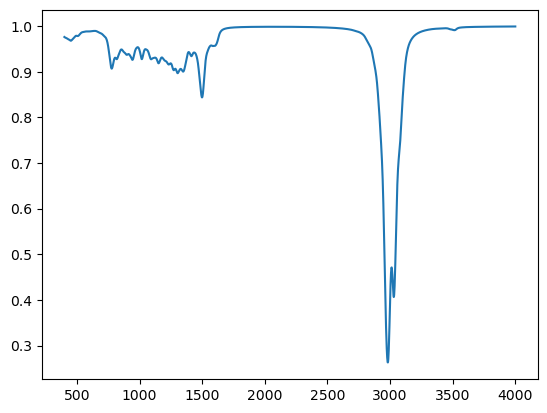

In [56]:
x=np.array(df_4.columns[:2000]).astype(float)
y=np.array(df_4.iloc[65][:2000])
plt.plot(x,y)